# 🚀 Tutorial: Neural Differential Equations & Diffusion Models in JAX

Hướng dẫn này giúp bạn làm quen với JAX, xây dựng Mạng vi phân (NDE) và ứng dụng giải thuật ODE để huấn luyện Mô hình sinh Diffusion dựa trên điểm số (Score-based).



In [4]:
!pip install --upgrade --force-reinstall jax[cuda12]

  Using cached jax-0.10.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.2-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 7.1 MB/s eta 0:00:00
Using cached jaxlib-0.10.2-cp312-cp312-manylinux_2_27_x86_64.whl (85.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 67.2 MB/s eta 0:00:00
Using cached jax-0.10.2-py3-none-any.whl (3.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [1]:
!pip install diffrax

In [2]:
!pip install equinox

In [3]:
import gzip
import os
import struct
import urllib.request
import array

import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import diffrax as dfx
import equinox as eqx
from equinox import nn
import matplotlib.pyplot as plt
import numpy as np

## 🛠️ Phần 1: Làm quen với tư duy Lập trình hàm của JAX

Để chạy mượt mà các mô hình vi phân liên tục, JAX dựa trên 3 trụ cột cốt lõi:

* **Statelessness (Không trạng thái):** Hàm số trong JAX phải là *Pure Function* (không thay đổi biến môi trường ngầm). Trọng số mạng thần kinh (`params`) được tách riêng thành một Dictionary thuần túy, thay vì lưu cấu trúc ẩn bên trong mô hình như PyTorch.
* **`@jax.jit` (Just-In-Time Compilation):** Biên dịch mã nguồn Python thẳng xuống XLA để tối ưu hóa hiệu năng, giúp tính toán ma trận và đạo hàm chạy cực nhanh trên GPU/TPU.
* **`@jax.vmap` (Automatic Vectorization):** Viết thuật toán cho **1 điểm dữ liệu đơn lẻ**, sau đó ép JAX tự động chạy song song (batching) trên hàng ngàn điểm mà không cần dùng vòng lặp `for`.


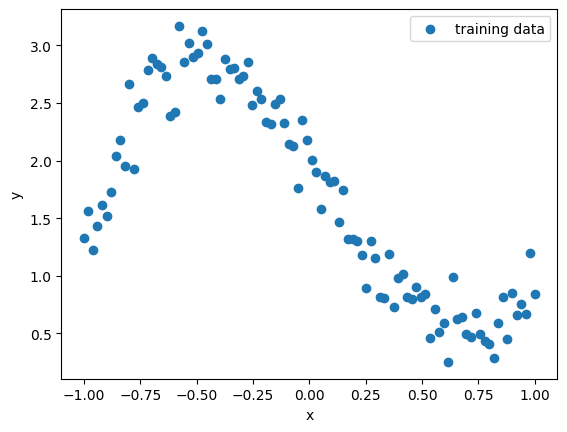

In [4]:
key = jr.key(0)
x_batch = jnp.linspace(-1, 1, 100).reshape((100,1))
y_label_batch = 3*x_batch**3 - x_batch**2 - 3*x_batch + 2 + 0.2*jax.random.normal(key, (100,1))
#y=3x^3-x_2-3x+2
plt.scatter(x_batch, y_label_batch, label="training data")
plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [5]:
def forward(theta, x):
    "Returns model prediction, for a single example input"
    y = theta[0]*x**3 + theta[1]*x**2 + theta[2]*x + theta[3]
    return y

forward_batch = jax.vmap(forward, in_axes=(None, 0))# batched version of forward

theta = jnp.zeros(4, dtype=float)
print(forward_batch(theta, x_batch).shape)

(100, 1)


In [6]:
def loss(theta, x_batch, y_label_batch):
    "Computes mean squared error between model prediction and training data"
    y_batch = forward_batch(theta, x_batch)
    loss = jnp.mean((y_batch-y_label_batch)**2)
    return loss

grad = jax.value_and_grad(loss, argnums=0)# gradient of loss wrt model parameters

print(grad(theta, x_batch, y_label_batch)[1])

[ 0.3481606 -0.9725055  0.7914293 -3.3635864]


In [7]:
def step(lrate, theta, x_batch, y_label_batch):
    "Performs one gradient descent step on model parameters, given training data"
    lossval, dldt = grad(theta, x_batch, y_label_batch)
    theta = jax.tree_util.tree_map(lambda t,dt: t-lrate*dt, theta, dldt)
    return theta, lossval

jit_step = jax.jit(step)# makes step go brr

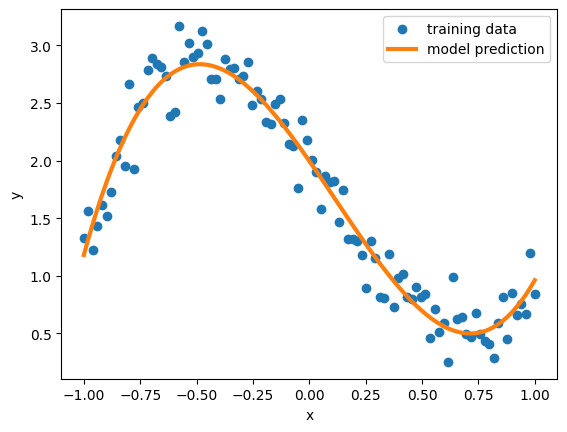

[ 2.7081442 -0.926273  -2.8177867  1.9967881]


In [8]:
# initialise theta
theta = jnp.zeros(4, dtype=float)

# run gradient descent
for i in range(1000):
    theta, lossval = jit_step(0.1, theta, x_batch, y_label_batch)

plt.scatter(x_batch, y_label_batch, label="training data")
plt.plot(x_batch, forward_batch(theta, x_batch), color="tab:orange", lw=3, label="model prediction")
plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()
print(theta)

In [ ]:
%timeit jit_step(0.1, theta, x_batch, y_label_batch)[1].block_until_ready()
%timeit step(0.1, theta, x_batch, y_label_batch)[1].block_until_ready()

85.5 µs ± 43 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
15.3 ms ± 1.87 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 📝 Task 2: Neural Differential Equations with JAX (Mô hình Lotka-Volterra)

Trong bài tập này, chúng ta nghiên cứu cách mô phỏng hệ động lực học phi tuyến **Lotka-Volterra** (mô hình tương tác giữa Con mồi và Thợ săn). Mục tiêu cốt lõi là làm quen với việc xây dựng bộ giải phương trình vi phân bằng thuật toán **Runge-Kutta bậc 4 (RK4)** và tối ưu hóa vòng lặp tính toán bằng các hàm nguyên thủy của JAX.

---

### 1. Hệ phương trình Lotka-Volterra

Hệ thống được mô tả bởi hai phương trình vi phân thường (ODE) ràng buộc lẫn nhau:

$$\frac{dx}{dt} = \alpha x - \beta xy$$

$$\frac{dy}{dt} = \gamma xy - \delta y$$

**Ý nghĩa các thành phần:**
* $x$: Mật độ quần thể của **Con mồi** (Prey).
* $y$: Mật độ quần thể của **Thợ săn** (Predator).
* $\alpha, \beta$: Tốc độ tăng trưởng tự nhiên của con mồi và hệ số con mồi bị săn bắn.
* $\delta, \gamma$: Tốc độ chết tự nhiên của thợ săn và hệ số tăng trưởng của thợ săn nhờ nguồn thức ăn.

Để lập trình hệ thức này, ta xây dựng một hàm số $\mathbf{f}(\mathbf{x}, *\mathbf{fargs})$ đóng vai trò là **Vế phải (RHS)** của phương trình, nhận đầu vào là trạng thái hiện tại $\mathbf{x} = (x, y)$ và các hệ số tương tác $\mathbf{fargs} = (\alpha, \beta, \gamma, \delta)$, sau đó trả về vector vận tốc thay đổi $(\dot{x}, \dot{y})$.

---

### 2. Thuật toán tích phân Runge-Kutta bậc 4 (RK4)

Thay vì sử dụng phương pháp Euler dạng tuyến tính thô sơ (dễ bị tích tụ sai số lớn theo thời gian), bài toán yêu cầu sử dụng bộ giải **Runge-Kutta bậc 4 (RK4)** tất định. Tại mỗi bước thời gian $\Delta t$, trạng thái tiếp theo $\mathbf{x}_{t+1}$ được cập nhật từ trạng thái hiện tại $\mathbf{x}_t$ thông qua việc lấy trung bình trọng số của 4 hệ số dự đoán độ dốc ($k_1, k_2, k_3, k_4$):

$$\mathbf{x}_{t+1} = \mathbf{x}_t + \frac{\Delta t}{6}(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4)$$

**Công thức tính các hệ số độ dốc:**
* $\mathbf{k}_1 = \mathbf{f}(\mathbf{x}_t)$ — Độ dốc tại điểm bắt đầu khoảng thời gian.
* $\mathbf{k}_2 = \mathbf{f}\left(\mathbf{x}_t + \frac{\Delta t \mathbf{k}_1}{2}\right)$ — Độ dốc tại điểm giữa khoảng thời gian (dựa trên $k_1$).
* $\mathbf{k}_3 = \mathbf{f}\left(\mathbf{x}_t + \frac{\Delta t \mathbf{k}_2}{2}\right)$ — Độ dốc tại điểm giữa khoảng thời gian (dựa trên $k_2$).
* $\mathbf{k}_4 = \mathbf{f}(\mathbf{x}_t + \Delta t \mathbf{k}_3)$ — Độ dốc tại điểm cuối khoảng thời gian.

---

### 3. Tối ưu hóa hiệu năng bằng `jax.lax.scan`

Một trong những yêu cầu kỹ thuật quan trọng của bài tập là không sử dụng vòng lặp `for` thông thường của Python để chạy bộ giải ODE, mà phải thay thế bằng **`jax.lax.scan`**.

**Lý do cần sử dụng `jax.lax.scan`:**
* **Giảm thời gian biên dịch (Compile-time):** Nếu dùng vòng lặp `for` của Python với $N = 1000$ bước, trình biên dịch JIT của JAX sẽ phải "unroll" (trải phẳng) toàn bộ 1000 bước tính toán thành một đồ thị tĩnh khổng lồ, gây tràn bộ nhớ hoặc làm chậm quá trình biên dịch.
* **Biên dịch lặp nguyên thủy:** `jax.lax.scan` dịch vòng lặp thành một cấu trúc lặp duy nhất ở cấp độ mã máy XLA. Trình biên dịch chỉ cần biên dịch bước tính toán RK4 đúng một lần duy nhất, sau đó tái sử dụng cấu trúc đó cho toàn bộ các bước thời gian.
* **Quản lý trạng thái thông minh:** Hàm này tự động thu thập mảng lịch sử các trạng thái $\mathbf{X} = (\mathbf{x}_0, \mathbf{x}_1, \dots, \mathbf{x}_T)$ dưới dạng một mảng có kích thước định sẵn `(N + 1, 2)`, tối ưu hóa bộ nhớ đệm trên GPU/TPU.

(501, 2)


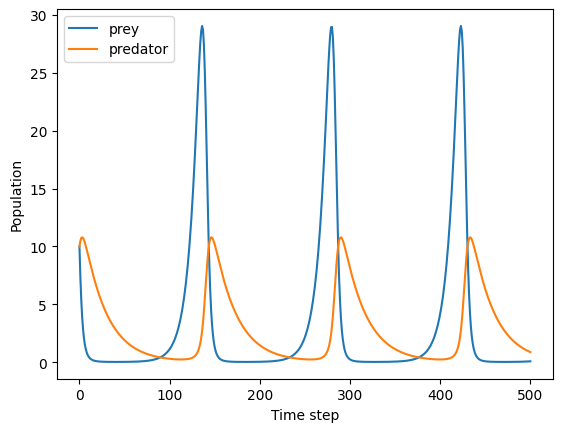

In [9]:
def f(x, alpha, beta, gamma, delta):
    "Computes RHS of Lotka-Volterra ODE"
    x, y = alpha*x[0:1]-beta*x[0:1]*x[1:2], gamma*x[0:1]*x[1:2]-delta*x[1:2]
    f = jnp.concatenate([x,y], axis=0)
    return f

def ode_solver(x0, N, dt, f, fargs):
    "Generic 4th order explicit RK ODE solver. f(x, *fargs) is a function which computes the RHS of the ODE."

    def single_step(x, i):
        k1 = f(x, *fargs)
        k2 = f(x+dt*k1/2, *fargs)
        k3 = f(x+dt*k2/2, *fargs)
        k4 = f(x+dt*k3, *fargs)
        x = x + (dt/6)*(k1+2*k2+2*k3+k4)
        return x, x

    _, X = jax.lax.scan(single_step, x0, jnp.arange(N))
    X = jnp.concatenate([x0.reshape((1,-1)), X], axis=0)

    return X

# solve LV system
x0 = jnp.array([10.,10.])
N = 500
dt = 0.1
fargs = (1.1, 0.4, 0.1, 0.4)# alpha, beta, gamma, delta
X = ode_solver(x0, N, dt, f, fargs)
print(X.shape)

# plot solution
def plot_solution(X, scatter=False, show=True):
    plt.figure()
    if scatter:
        plt.scatter(jnp.arange(X.shape[0]), X[:,0], alpha=0.8, label="prey")
        plt.scatter(jnp.arange(X.shape[0]), X[:,1], alpha=0.8, label="predator")
    else:
        plt.plot(X[:,0], label="prey")
        plt.plot(X[:,1], label="predator")
    plt.ylabel("Population")
    plt.xlabel("Time step")
    plt.legend()
    if show:
        plt.show()
plot_solution(X)

## 🧠 Task 2 (Tiếp theo): Tìm kiếm thành phần động lực học chưa biết (Universal ODEs)

Trong phần này, chúng ta giả định rằng một vài thành phần trong hệ phương trình vi phân (ODE) bị ẩn hoặc chưa được biết rõ trong thực tế, và mục tiêu của chúng ta là **học (learn)** chúng từ dữ liệu quan sát. Đây chính là triết lý của **Universal Differential Equations (UDEs)**.

---

### 1. Hệ phương trình hiệu chỉnh với Mạng thần kinh

Thay vì sử dụng toàn bộ mô hình toán học thuần túy, chúng ta nhúng một mạng thần kinh và một tham số có thể tối ưu hóa trực tiếp vào hệ phương trình:

$$\frac{dx}{dt} = NN(x; \theta_1) - \beta xy$$

$$\frac{dy}{dt} = \gamma xy - \theta_2 y$$

**Ý nghĩa của các thành phần mới:**
* $NN(x; \theta_1)$: Một mạng thần kinh (Neural Network) với bộ trọng số $\theta_1$. Mạng này nhận đầu vào là mật độ con mồi $x$ và có nhiệm vụ tự xấp xỉ quy luật sinh trưởng tự nhiên của chúng thay vì cố định bằng công thức $\alpha x$.
* $\theta_2$: Một hằng số thực (scalar) có thể huấn luyện được, đại diện cho tỷ lệ chết tự nhiên chưa biết của thợ săn (thay thế cho hệ số hằng số $\delta$ cố định trước đó).
* **Các tham số đã biết:** $\beta = 0.2$ và $\gamma = 0.1$.

---

### 2. Phương pháp Huấn luyện (Training Strategy)

Để đồng thời tối ưu hóa cả trọng số của mạng thần kinh $\theta_1$ và tham số tự do $\theta_2$, chúng ta sẽ thực hiện các bước sau:

1. **Khởi tạo:** Gom nhóm các tham số cần học thành một cấu trúc dữ liệu duy nhất trong JAX: `params = {'nn': theta_1, 'theta_2': theta_2}`.
2. **Tích phân hệ thống:** Sử dụng bộ giải `ode_solver` (thuật toán RK4 kết hợp với `jax.lax.scan` đã viết ở phần trước) để giải hệ phương trình từ trạng thái ban đầu $x_0$ nhằm thu được chuỗi dự đoán theo thời gian.
3. **Tính toán hàm Loss:** Đo lường mức độ sai lệch giữa chuỗi dự đoán từ mô hình lai và chuỗi dữ liệu quan sát thực tế (Observations) bằng hàm lỗi bình phương trung bình (MSE).
4. **Lan truyền ngược bằng JAX:** Sử dụng `jax.value_and_grad` để tính toán chính xác gradient của hàm loss theo cả biến cấu trúc mạng $\theta_1$ và biến scalar $\theta_2$, sau đó cập nhật chúng qua các bước lặp bằng `optax`.

(200, 2)


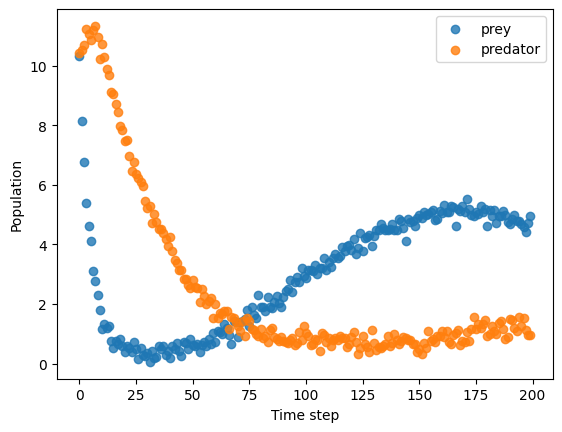

In [ ]:
def f_true(x):
    "Computes RHS of Lotka-Volterra ODE"
    x, y = jax.nn.tanh(x[0:1])-0.2*x[0:1]*x[1:2], 0.1*x[0:1]*x[1:2]-0.4*x[1:2]
    f = jnp.concatenate([x,y], axis=0)
    return f
_s = ode_solver(x0=jnp.array([10.,10.]), N=199, dt=0.1, f=f_true, fargs=())
np.save("X_obs.npy", _s+0.2*jr.normal(jr.key(0),_s[:200].shape))
del _s

X_obs = jnp.array(np.load("X_obs.npy"))
print(X_obs.shape)
plot_solution(X_obs, scatter=True)

## 🏗️ Task 2 (Tiếp theo): Định nghĩa Mạng thần kinh với Equinox

Để xấp xỉ thành phần động lực học chưa biết $NN(x; \theta_1)$ trong hệ phương trình, bài toán yêu cầu sử dụng thư viện **Equinox** (một thư viện xây dựng mạng thần kinh dạng hướng hàm cực kỳ mạnh mẽ và tương thích hoàn toàn với các cơ chế JIT, Vmap của JAX).

---

### Cấu trúc Mạng thần kinh yêu cầu

Mạng thần kinh của chúng ta sẽ được thiết kế với kiến trúc mạng kết nối đầy đủ (Fully Connected / MLP) đơn giản bao gồm:
* **Đầu vào (Input):** Nhận vào giá trị mật độ con mồi $x$ (một giá trị vô hướng - scalar, hoặc tensor kích thước 1 chiều).
* **Tầng ẩn (Hidden Layer):** Gồm **1 tầng ẩn** (1 hidden layer). Số lượng neuron trong tầng ẩn này là một siêu tham số (hyperparameter) có thể tùy chọn (ví dụ: 32 hoặc 64).
* **Hàm kích hoạt (Activation Function):** Sử dụng hàm **`tanh`** (`jnp.tanh`) sau tầng ẩn để tạo tính phi tuyến cho mô hình.
* **Đầu ra (Output):** Trả về **1 giá trị vô hướng duy nhất (scalar)**, tương ứng với giá trị tốc độ sinh trưởng tự nhiên được dự đoán tại điểm $x$ hiện tại.

---

### Ý nghĩa của việc chọn thư viện Equinox trong bài toán này

* **Trạng thái tường minh (Explicit State):** Equinox định nghĩa mô hình dưới dạng một `eqx.Module`. Khác với PyTorch, mọi trọng số và bias của mô hình Equinox đều là các mảng JAX (`jax.Array`) thuần túy lưu trữ công khai.
* **Tách lọc dữ liệu (Filtering):** Khi tính toán đạo hàm hệ thống vi phân, ta có thể dùng `eqx.filter_grad` hoặc các hàm lọc của Equinox để tách biệt đâu là trọng số mạng thần kinh cần tối ưu, đâu là các tham số tĩnh (như cấu trúc mạng), giúp việc truyền ngược (backpropagation) qua bộ giải ODE diễn ra chính xác mà không gặp lỗi cấu trúc đồ thị.

In [ ]:
class FCN(eqx.Module):
    "Fully-connected neural network, with 1 hidden layer"

    input_layer: nn.Linear
    hidden_layer: nn.Linear
    output_layer: nn.Linear

    def __init__(self, in_size, hidden_size, out_size, key):
        "Initialise network parameters"

        key1, key2, key3 = jr.split(key, 3)
        self.input_layer = nn.Linear(in_size, hidden_size, key=key1)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, key=key2)
        self.output_layer = nn.Linear(hidden_size, out_size, key=key3)

    def __call__(self, x):
        "Defines forward model"

        x = (x/10)-0.5# normalise input to expected range (given observational data)
        x = jax.nn.tanh(self.input_layer(x))
        x = jax.nn.tanh(self.hidden_layer(x))
        x = self.output_layer(x)
        return x

# create a network with 32 hidden units
key = jr.key(0)
model = FCN(1,32,1,key)
print(model)

FCN(
  input_layer=Linear(
    weight=f32[32,1],
    bias=f32[32],
    in_features=1,
    out_features=32,
    use_bias=True
  ),
  hidden_layer=Linear(
    weight=f32[32,32],
    bias=f32[32],
    in_features=32,
    out_features=32,
    use_bias=True
  ),
  output_layer=Linear(
    weight=f32[1,32], bias=f32[1], in_features=32, out_features=1, use_bias=True
  )
)


## ⚙️ Task 2 (Tiếp theo): Hàm Vế phải Mới cho Hệ Vi phân mạng thần kinh (NDE RHS)

Để tiến hành giải hệ phương trình lai bằng bộ giải `ode_solver`, chúng ta cần xây dựng một hàm vế phải mới $\mathbf{f}(\mathbf{x}, *\mathbf{fargs})$ tích hợp mạng thần kinh.

---

### Yêu cầu thiết kế hàm:

* **Đầu vào:** Trạng thái hiện tại $\mathbf{x} = (x, y)$ và các đối số mở rộng `fargs = (model, theta2)`.
    * `model`: Chính là mạng thần kinh Equinox đóng vai trò xấp xỉ hàm số $NN(x; \theta_1)$.
    * `theta2`: Tham số tự do cần học (tốc độ chết của thợ săn).
* **Giá trị cố định (Hard-coded):** Hai hệ số $\beta = 0.2$ và $\gamma = 0.1$ sẽ được khai báo cố định trực tiếp bên trong thân hàm, không truyền từ ngoài vào qua `fargs`.
* **Hệ thức tính toán:**
    * $\dot{x} = \text{model}(x) - 0.2 \cdot xy$
    * $\dot{y} = 0.1 \cdot xy - \theta_2 \cdot y$
* **Đầu ra:** Trả về một mảng JAX `jnp.array([\dot{x}, \dot{y}])` đại diện cho vận tốc thay đổi tại bước thời gian hiện tại.

In [ ]:
def f(x, model, theta2):
    "Computes RHS of Lotka-Volterra NDE"
    x, y = model(x[0:1])-0.2*x[0:1]*x[1:2], 0.1*x[0:1]*x[1:2]-theta2*x[1:2]
    f = jnp.concatenate([x,y], axis=0)
    return f

## 📉 Task 2 (Tiếp theo): Định nghĩa Hàm Loss và Kiểm tra Mô hình (Loss Function & Baseline)

Bước cuối cùng trước khi huấn luyện là thiết lập hàm mục tiêu (Loss Function) để ép mô hình lai (NDE) khớp với dữ liệu quan sát thực tế.

---

### 1. Ý đồ của Hàm Loss (MSE)
Hàm loss nhận vào bộ tham số cần tối ưu, kích hoạt bộ giải `ode_solver` kết hợp với hàm vế phải `f` chứa mạng thần kinh để sinh ra chuỗi dự đoán nghiệm $\mathbf{X}_{pred}$ từ trạng thái ban đầu $\mathbf{x}_0$.

Sai số được tính bằng lỗi bình phương trung bình (**Mean Squared Error - MSE**) giữa chuỗi nghiệm dự đoán và dữ liệu quan sát thực tế `X_obs`:

$$\text{Loss} = \frac{1}{N+1} \sum_{t=0}^{T} ||\mathbf{X}_{pred, t} - \mathbf{X}_{obs, t}||^2$$

> **Thông số cấu hình dữ liệu quan sát:** Trạng thái gốc $x_0 = [10.0, 10.0]$, bước thời gian $dt = 0.1$, số bước tích phân $N = 199$.

---

### 2. Kiểm tra sơ bộ (Sanity Check)
Trước khi chạy tối ưu hóa với `optax`, ta cần thực hiện một bước kiểm tra điều kiện nền (Baseline Check):
* **Cấu hình thử nghiệm:** Sử dụng một mạng thần kinh hoàn toàn chưa qua huấn luyện (trọng số ngẫu nhiên) và đặt tham số $\theta_2 = 0$.
* **Mục tiêu kiểm tra:** 1. Hàm Loss phải trả về đúng **một giá trị vô hướng (scalar)** duy nhất để thuật toán có thể tính được Gradient (`jax.grad`).
    2. Vẽ đồ thị chuỗi nghiệm NDE lúc này để thấy sự sai lệch lớn (do chưa học) so với dữ liệu gốc `X_obs`, làm cơ sở đối chiếu sau khi huấn luyện thành công.

94.302956


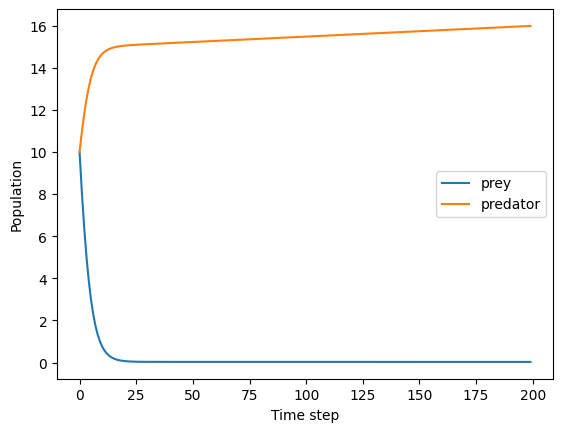

In [ ]:
def loss(x0, N, dt, f, fargs, X_obs):
    "Computes mean squared error between NDE solution and observed data"
    X = ode_solver(x0, N, dt, f, fargs)
    loss = jnp.mean((X-X_obs)**2)
    return loss

# solve untrained NDE
x0 = jnp.array([10.,10.])
N = 199
dt = 0.1
fargs = (model, jnp.array(0.0))
print(loss(x0, N, dt, f, fargs, X_obs))
X = ode_solver(x0, N, dt, f, fargs)
plot_solution(X)

## 🚀 Task 2 (Tiếp theo): Huấn luyện và Đánh giá kết quả NDE (Training & Evaluation)

Sau khi chuẩn bị đầy đủ các thành phần (Hàm vế phải lai, Bộ giải ODE, và Hàm Loss), chúng ta tiến hành bước huấn luyện chính thức để mô hình tự phục dựng động lực học ẩn từ dữ liệu.

---

### 1. Cơ chế huấn luyện với Optax
Vòng lặp huấn luyện triển khai thuật toán hạ gradient tiêu chuẩn (**Gradient Descent Loop**) sử dụng thư viện **Optax**:
* **Tính toán Đạo hàm:** Kết hợp `eqx.filter_value_and_grad` (hoặc `jax.value_and_grad`) để tự động tính gradient của hàm Loss theo các tham số cần học (trọng số mạng thần kinh $\theta_1$ và hằng số $\theta_2$).
* **Cập nhật Tham số:** Sử dụng bộ tối ưu hóa (ví dụ: `optax.adam`) để cập nhật trạng thái của các tham số sau mỗi bước lặp (`step`), ép giá trị lỗi MSE giảm dần về 0.

---

### 2. Đánh giá và So sánh Kết quả (Evaluation)
Sau khi quá trình huấn luyện hoàn tất, chúng ta tiến hành kiểm tra chất lượng mô hình:
* **Trực quan hóa đồ thị:** Sử dụng `ode_solver` với bộ tham số đã tối ưu để giải lại hệ thống, sau đó vẽ đồ thị chuỗi nghiệm dự đoán đè lên chuỗi dữ liệu quan sát gốc `X_obs`.
* **Mục tiêu:** Nếu quá trình tối ưu thành công, đường cong NDE đã huấn luyện sẽ khớp hoàn hảo (hoặc bám cực kỳ sát) với đồ thị của dữ liệu thực tế, minh chứng rằng mạng thần kinh đã học được chính xác quy luật sinh trưởng ẩn của con mồi và hằng số tử vong $\theta_2$ của thợ săn.

[1/2000] loss: 94.3029556274414


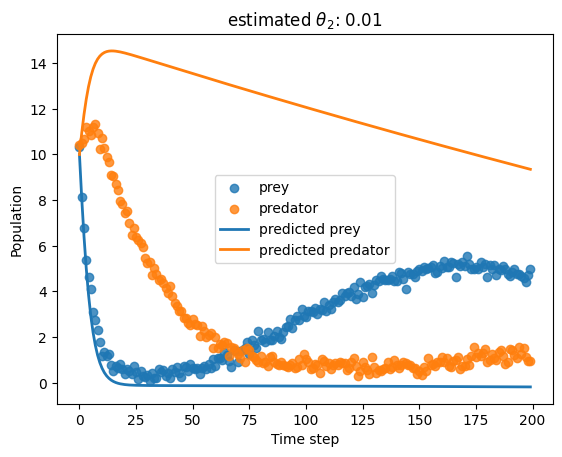

[500/2000] loss: 0.04670919477939606


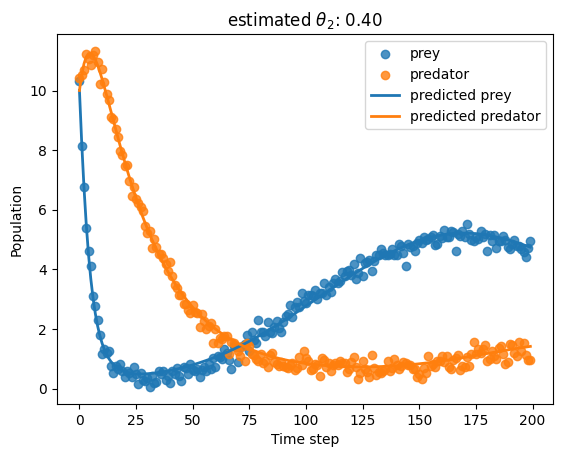

[1000/2000] loss: 0.03878716006875038


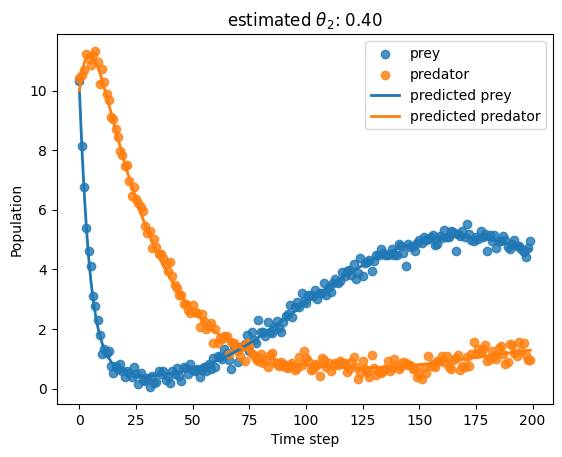

[1500/2000] loss: 0.038159437477588654


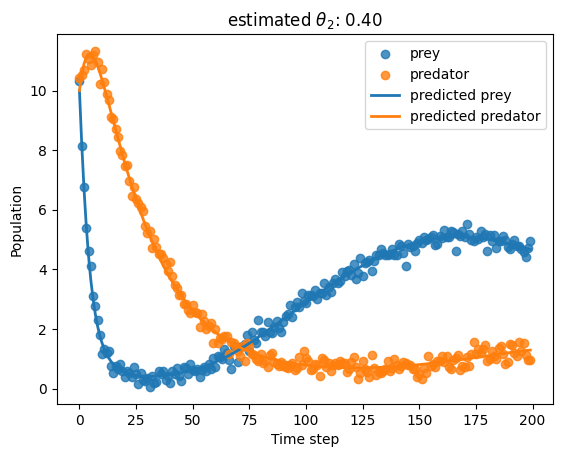

[2000/2000] loss: 0.03787388652563095


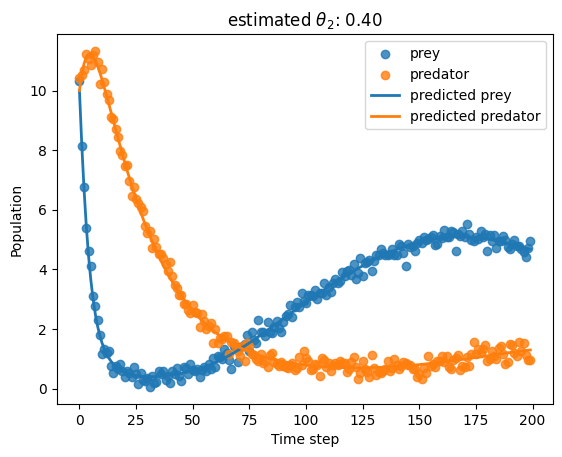

In [ ]:
def grad(x0, N, dt, f, fargs, X_obs):
    "Computes gradient of loss function wrt fargs"
    partial = lambda fargs: loss(x0, N, dt, f, fargs, X_obs)
    return eqx.filter_value_and_grad(partial)(fargs)

@eqx.filter_jit
def step(x0, N, dt, f, fargs, X_obs, opt_state, opt_update):
    "Performs one gradient descent step on fargs"
    lossval, grads = grad(x0, N, dt, f, fargs, X_obs)
    updates, opt_state = opt_update(grads, opt_state)
    fargs = eqx.apply_updates(fargs, updates)
    return lossval, fargs, opt_state

x0 = jnp.array([10.,10.])
N = 199
dt = 0.1

# initialise learnable parts
key = jr.key(0)
model = FCN(1,32,1,key)
fargs = (model, jnp.array(0.0))

# define optimiser
optimiser = optax.adam(learning_rate=1e-2)
opt_state = optimiser.init(eqx.filter(fargs, eqx.is_array))
opt_update = optimiser.update
n_steps = 2000

# train NDE
lossvals = []
for i in range(n_steps):
    lossval, fargs, opt_state = step(x0, N, dt, f, fargs, X_obs, opt_state, opt_update)
    lossvals.append(lossval)
    if (i+1)%500==0 or i==0:
        print(f"[{i+1}/{n_steps}] loss: {lossval}")

        # plot result
        X = ode_solver(x0, N, dt, f, fargs)
        plot_solution(X_obs, scatter=True, show=False)
        plt.plot(X[:,0], lw=2, label="predicted prey")
        plt.plot(X[:,1], lw=2, label="predicted predator")
        plt.legend()
        plt.title(f"estimated $\\theta_2$: {fargs[1]:.2f}")
        plt.show()

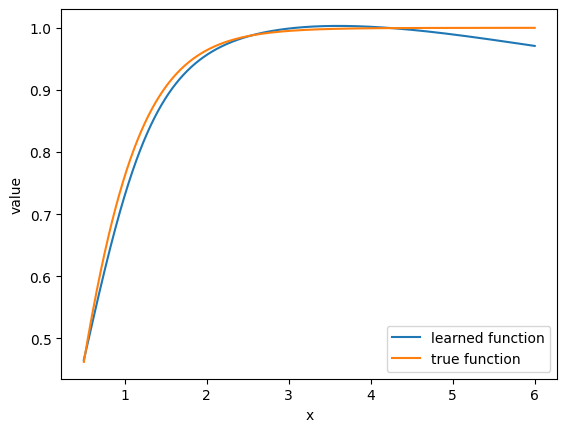

In [ ]:
x = jnp.linspace(0.5,6,1000).reshape(-1,1)
plt.figure()
plt.plot(x, jax.vmap(lambda x: fargs[0](x))(x), label="learned function")
plt.plot(x, jax.nn.tanh(x), label="true function")
plt.legend()
plt.xlabel("x")
plt.ylabel("value")
plt.show()

## 🌌 Task 3: Score-based diffusion model with JAX

Trong bài tập này, chúng ta sẽ huấn luyện một mô hình sinh **Score-based Diffusion Model** để tạo ra các hình ảnh chữ số viết tay mới từ bộ dữ liệu huấn luyện mẫu **MNIST**.

---

### Ý đồ toán học của Mô hình Khuếch tán (Diffusion Model)

Mục tiêu cốt lõi của bài toán là học cách **đảo ngược quá trình khuếch tán (reverse-diffuse)** để biến đổi cấu trúc dữ liệu:

1. **Phân phối tiên nghiệm ($p_T(\mathbf{x})$):** Xuất phát từ một tập mẫu ngẫu nhiên dạng nhiễu vô định hình được lấy từ phân phối Gaussian đa biến độc lập (multivariate Gaussian with i.i.d. variables).
2. **Phân phối mục tiêu ($p_0(\mathbf{x})$):** Từng bước khử nhiễu tất định để đưa mẫu ngẫu nhiên đó về dạng một mẫu hợp lệ thuộc phân phối dữ liệu gốc chứa toàn bộ các ảnh chữ số viết tay MNIST khả dĩ.
3. **Ma trận điểm ảnh ($\mathbf{x}$):** Trong toàn bộ quá trình này, $\mathbf{x}$ được định nghĩa là một ma trận chứa các giá trị pixel của bức ảnh cần sinh ra.

---

### Bước 1: Nạp dữ liệu huấn luyện (Load Training Data)
Hệ thống sẽ tiến hành tải và tiền xử lý tập dữ liệu hình ảnh MNIST (chuẩn hóa giá trị pixel, định hình lại tensor) để làm cơ sở dữ liệu gốc cho mạng neural học hàm điểm số (score function).

Downloaded https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz to /content/data/mnist/train-images-idx3-ubyte.gz
(60000, 1, 28, 28)


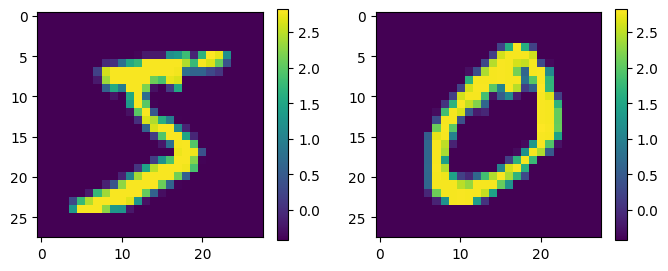

In [10]:
def mnist():
    "Downloads and loads MNIST dataset"
    filename = "train-images-idx3-ubyte.gz"
    url_dir = "https://storage.googleapis.com/cvdf-datasets/mnist"
    target_dir = os.getcwd() + "/data/mnist"
    url = f"{url_dir}/{filename}"
    target = f"{target_dir}/{filename}"

    if not os.path.exists(target):
        os.makedirs(target_dir, exist_ok=True)
        urllib.request.urlretrieve(url, target)
        print(f"Downloaded {url} to {target}")

    with gzip.open(target, "rb") as fh:
        _, batch, rows, cols = struct.unpack(">IIII", fh.read(16))
        shape = (batch, 1, rows, cols)
        return jnp.array(array.array("B", fh.read()), dtype=jnp.uint8).reshape(shape)

data = mnist()
data = (data - jnp.mean(data)) / jnp.std(data)# normalise
print(data.shape)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(data[0,0])
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(data[1,0])
plt.colorbar()
plt.show()

## 📐 Task 3 (Tiếp theo): Lấy mẫu bằng cách giải ngược Probability Flow ODE

Để sinh ảnh từ nhiễu, chúng ta sẽ thiết lập quá trình lấy mẫu từ phân phối $p_0(\mathbf{x})$ thông qua việc giải ngược một phương trình vi phân thường tất định gọi là **Probability Flow ODE**.

---

### 1. Nền tảng Toán học (Từ SDE sang ODE)

Quá trình khuếch tán tiến (forward) biến đổi ảnh gốc $\mathbf{x}_0 \sim p_0(\mathbf{x})$ thành nhiễu $\mathbf{x}_T \sim p_T(\mathbf{x})$ được định nghĩa bởi phương trình vi phân ngẫu nhiên (SDE):
$$d\mathbf{x} = \mathbf{f}(\mathbf{x},t)dt + g(t)d\mathbf{w}$$

Khi đó, phương trình **Probability Flow ODE** tương ứng có cùng mật độ phân phối biên tại mọi thời điểm $t$ được xác định bằng công thức:
$$\frac{d\mathbf{x}}{dt} = \mathbf{f}(\mathbf{x},t) - \frac{1}{2}g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})$$

Khi giải phương trình ODE này ngược thời gian (từ $t = T$ về $t = 0$) với điều kiện đầu là nhiễu $\mathbf{x}_T \sim p_T(\mathbf{x})$, nghiệm thu được tại đích đến chính là một bức ảnh sinh mới hợp lệ $\mathbf{x}_0 \sim p_0(\mathbf{x})$.

---

### 2. Mô hình biến đổi phương sai cố định (Variance Preserving SDE)

Bài toán giả định mô hình khuếch tán tiến tuân theo quy luật **VP-SDE** với hàm điều tiết nhiễu $\beta(t)$:
$$d\mathbf{x} = -\frac{1}{2}\beta(t)\mathbf{x}dt + \sqrt{\beta(t)}d\mathbf{w}$$

Thế các hệ số vào, ta thu được phương trình Probability Flow ODE cụ thể cho bài toán:
$$\frac{d\mathbf{x}}{dt} = -\frac{1}{2}\beta(t)\mathbf{x} - \frac{1}{2}\beta(t) \nabla_\mathbf{x} \log p_t(\mathbf{x})$$

---

### 3. Xấp xỉ Hàm Điểm số bằng U-Net

Mục tiêu huấn luyện của mạng thần kinh là học **Hàm điểm số (Score Function)**: $\mathbf{s}(\mathbf{x}, t; \theta) \approx \nabla_\mathbf{x} \log p_t(\mathbf{x})$. Sau khi mạng được huấn luyện xong, ta chỉ cần giải phương trình NDE tất định sau để lấy mẫu:

$$\frac{d\mathbf{x}}{dt} = -\frac{1}{2}\beta(t)\mathbf{x} - \frac{1}{2}\beta(t)\mathbf{s}(\mathbf{x}, t; \theta)$$

* **Kiến trúc mạng:** Sử dụng mạng **U-Net** để ước lượng hàm điểm số.
* **Cấu hình đầu vào:** Mạng nhận bức ảnh $\mathbf{x}$ và thời điểm $t$. Biến thời gian $t$ sẽ được lặp lại (repeat) thành một chiều ma trận và nối trực tiếp (`concatenate`) vào ảnh như một kênh đầu vào bổ sung (extra input channel). Đầu ra của U-Net là một tensor có cùng kích thước hình học với $\mathbf{x}$.

In [11]:
def relu_layer(x, key=None):
    return jax.nn.relu(x)

class UNet(eqx.Module):
    down_conv_blocks: list
    max_pools: list
    conv_transposes: list
    up_conv_blocks: list
    conv_final: nn.Conv2d
    n_levels: int

    def __init__(self, in_channels, out_channels, n_hidden, n_levels, n_width, key):

        key1,key2,key3,key4 = jr.split(key, 4)
        self.n_levels = n_levels

        # downsampling and middle convolutional blocks
        self.down_conv_blocks = [
            nn.Sequential(
                ([nn.Conv2d(n_hidden*(2**(il-1)) if il!=0 else in_channels, n_hidden*(2**(il)), kernel_size=3, stride=1, padding=1, key=key1)]+
                  [relu_layer]+
                  ([nn.Sequential(
                    ([nn.Conv2d(n_hidden*(2**(il)), n_hidden*(2**(il)), kernel_size=3, stride=1, padding=1, key=key2)]+
                      [relu_layer])
                    ) for key1,key2 in jr.split(key, (n_width, 2))])
                  )
                )
            for il,key in enumerate(jr.split(key1, n_levels+1))]

        # pooling operations
        self.max_pools = [
                nn.MaxPool2d(kernel_size=2, stride=2)
            for il in range(n_levels)]

        # transposed convolutions
        self.conv_transposes = [
                nn.ConvTranspose2d(n_hidden*(2**(n_levels-il)), n_hidden*(2**(n_levels-il-1)), kernel_size=2, stride=2, key=key)
            for il,key in enumerate(jr.split(key2, n_levels))]

        # upsampling convolutional blocks
        self.up_conv_blocks = [
            nn.Sequential(
                ([nn.Conv2d(n_hidden*(2**(n_levels-il)), n_hidden*(2**(n_levels-il-1)), kernel_size=3, stride=1, padding=1, key=key1)]+
                  [relu_layer]+
                  ([nn.Sequential(
                    ([nn.Conv2d(n_hidden*(2**(n_levels-il-1)), n_hidden*(2**(n_levels-il-1)), kernel_size=3, stride=1, padding=1, key=key2)]+
                      [relu_layer])
                    ) for key1,key2 in jr.split(key, (n_width, 2))])
                  )
                )
            for il,key in enumerate(jr.split(key3, n_levels))]

        self.conv_final = nn.Conv2d(n_hidden, out_channels, kernel_size=1, stride=1, key=key4)

    def __call__(self, x, t, t1):
        print(x.shape, t.shape)
        x = jnp.concatenate([x,jnp.tile(t/t1,x.shape)], axis=0)# simply add time as an extra channel
        print(x.shape)

        # downsampling blocks
        skips = []
        for il in range(self.n_levels):
            x = self.down_conv_blocks[il](x)
            skips.append(x)
            x = self.max_pools[il](x)
            print(x.shape)

        # middle block
        x = self.down_conv_blocks[-1](x)
        print(x.shape)

        # upsampling blocks
        for il in range(self.n_levels):
            x = self.conv_transposes[il](x)
            x = jnp.concatenate([x, skips[self.n_levels-il-1]], axis=0)
            x = self.up_conv_blocks[il](x)
            print(x.shape)

        x = self.conv_final(x)
        print(x.shape)

        return x

## 📉 Task 3 (Tiếp theo): Hàm Loss cho Score-based Diffusion Model

Để huấn luyện mạng điểm số $s(\mathbf{x}, t; \theta)$, chúng ta cần thiết lập một hàm mục tiêu dựa trên phương pháp **Denoising Score Matching**.

---

### 1. Hàm Loss tổng quát và Trọng số $\lambda(t)$

Hàm loss tổng quát cho mô hình khuếch tán continuous-time thường có dạng kỳ vọng:
$$\mathcal{L}(\theta) = \mathbb{E}_{t, \mathbf{x}_0 \sim p_0, \mathbf{x}_t \sim p_{t|0}(\mathbf{x}_t|\mathbf{x}_0)} \left[ \lambda(t) \left\| \mathbf{s}(\mathbf{x}_t, t; \theta) - \nabla_{\mathbf{x}_t} \log p_{t|0}(\mathbf{x}_t|\mathbf{x}_0) \right\|^2 \right]$$

Trong đó, hệ số trọng số $\lambda(t)$ được chọn để cân bằng đóng góp sai số ở các thời điểm $t$ khác nhau:
$$\lambda(t) = \mathbb{E} \left[ \left\| \nabla_{\mathbf{x}_t} \log p_{t|0}(\mathbf{x}_t|\mathbf{x}_0) \right\|^{-2} \right]$$

---

### 2. Đơn giản hóa hàm Loss cho Variance-Preserving SDE

Đối với mô hình **VP-SDE**, xác suất chuyển trạng thái từ ảnh gốc $\mathbf{x}_0$ sang ảnh nhiễu $\mathbf{x}_t$ tuân theo một phân phối chuẩn (Gaussian distribution) có dạng giải tích cụ thể:
$$p_{t|0}(\mathbf{x}_t|\mathbf{x}_0) = \mathcal{N}\left(\mathbf{x}_t; \mathbf{x}_0 e^{-\frac{1}{2}\int_0^t \beta(t)dt}, \left(1 - e^{-\int_0^t \beta(t)dt}\right)\mathbf{I}\right)$$

Đặt các hệ số thu gọn:
$$\mu = e^{-\frac{1}{2}\int_0^t \beta(t)dt}, \quad \sigma^2 = 1 - e^{-\int_0^t \beta(t)dt}$$

Khi đó, biến ngẫu nhiên $\mathbf{x}_t$ có thể biểu diễn qua nhiễu chuẩn $\mathbf{z} \sim \mathcal{N}(0, \mathbf{I})$ là $\mathbf{x}_t = \mu \mathbf{x}_0 + \sigma \mathbf{z}$, và hàm điểm số thực tế (true score) trở thành $\nabla_{\mathbf{x}_t} \log p_{t|0}(\mathbf{x}_t|\mathbf{x}_0) = -\frac{\mathbf{z}}{\sigma}$.

Thế tất cả vào hệ thống, ta có thể rút gọn hàm Loss về dạng thực nghiệm dễ tính toán như sau:
$$\mathcal{L}(\theta) = \mathbb{E}_{t, \mathbf{x}_0 \sim p_0, \mathbf{z} \sim \mathcal{N}(0, \mathbf{I})} \left[ \sigma^2 \left\| \mathbf{s}(\mu \mathbf{x}_0 + \sigma \mathbf{z}, t; \theta) + \frac{\mathbf{z}}{\sigma} \right\|^2 \right]$$

---

### 3. Yêu cầu lập trình hàm Loss đơn lẻ (Single Sample Loss)

Nhiệm vụ tiếp theo là viết một hàm `loss(model, int_beta, t1, x_0, t, key)` để tính toán giá trị loss trên cho đúng **một mẫu đơn lẻ** của cặp $(\mathbf{x}_0, t)$.

* **Tham số đầu vào:**
    * `model`: Mạng U-Net dự đoán score.
    * `int_beta`: Một hàm số cho trước, nhận vào $t$ và trả về giá trị tích phân của hệ số nhiễu: $\int_0^t \beta(t)dt$.
    * `x_0`: Ma trận ảnh gốc của một mẫu dữ liệu.
    * `t`: Thời điểm khuếch tán hiện tại (scalar).
    * `key`: PRNGKey của JAX dùng để sinh số ngẫu nhiên cho vector nhiễu $\mathbf{z}$.

In [12]:
def loss(model, int_beta, t1, x_0, t, key):
    "Loss value for a single x_0"

    # mean and variance of p(x_t|x_0)
    mean = x_0 * jnp.exp(-0.5 * int_beta(t))
    var = jnp.maximum(1 - jnp.exp(-int_beta(t)), 1e-5)# for numerical stability
    std = jnp.sqrt(var)

    # sample x_t from p(x_t|x_0)
    noise = jr.normal(key, x_0.shape)
    x_t = mean + std * noise

    # compute predicted score
    score = model(x_t, t, t1)

    # compute grad log p(x_t|x_0)
    glp = - noise / std

    # compute loss
    loss = var * jnp.mean((score - glp)**2)

    return loss

def loss_batch(model, int_beta, t1, x_0_batch, key):
    "Compute loss over batch of x_0, using random t for each example"

    batch_size = x_0_batch.shape[0]
    key, subkey = jr.split(key)

    # sample t values with low-discrepancy
    t_batch = jr.uniform(subkey, (batch_size,), minval=0, maxval=t1 / batch_size)
    t_batch = t_batch + (t1 / batch_size) * jnp.arange(batch_size)

    # evaluate losses
    key_batch = jr.split(key, batch_size)
    loss_batch = jax.vmap(loss, in_axes=(
        None, None, None, 0,0,0))(
        model, int_beta, t1, x_0_batch, t_batch, key_batch)

    return jnp.mean(loss_batch)

@eqx.filter_jit
def make_step(model, int_beta, t1, x_0_batch, opt_state, opt_update, key):
    "Carries out a gradient descent step to train score model"

    grad = eqx.filter_value_and_grad(loss_batch)
    lossval, grads = grad(model, int_beta, t1, x_0_batch, key)
    updates, opt_state = opt_update(grads, opt_state)
    model = eqx.apply_updates(model, updates)

    return lossval, model, opt_state

## 🌀 Task 3 (Tiếp theo): Lấy mẫu Đơn lẻ bằng bộ giải ngược ODE (Single Sample Generation)

Nhiệm vụ của phần này là viết hàm `single_sample_fn` để thực hiện quy trình sinh ra **một bức ảnh duy nhất** từ nhiễu thuần túy bằng cách giải ngược phương trình Probability Flow ODE từ thời điểm $t_1$ về $t=0$.

---

### Các bước xử lý trong Hàm:

1. **Khởi tạo Nhiễu (Prior Sampling):** Lấy mẫu ngẫu nhiên một tensor nhiễu Gaussian $\mathbf{x}_{t1} \sim \mathcal{N}(0, \mathbf{I})$ có cùng kích thước với ảnh MNIST để làm điều kiện biên ban đầu tại thời điểm $t_1$.
2. **Xây dựng Trường Vector cho bộ giải ODE:** Định nghĩa hàm vế phải $\mathbf{f}(\mathbf{x}, t)$ dựa trên phương trình tích phân lùi đã thiết lập:
   $$\frac{d\mathbf{x}}{dt} = -\frac{1}{2}\beta(t)\mathbf{x} - \frac{1}{2}\beta(t)\mathbf{s}(\mathbf{x}, t; \theta)$$
3. **Giải ngược hệ thống (Reverse Integration):** Gọi bộ giải `ode_solver` (thuật toán RK4 kết hợp `jax.lax.scan` từ Task 2) để tích phân lùi từ $t = t_1$ về $t = 0$ với bước thời gian $-dt_0$.

---

### 💡 Gợi ý tính nhanh hệ số $\beta(t)$ bằng `jax.jvp`

Vì bài toán chỉ cung cấp hàm tích phân `int_beta(t)` ($F(t) = \int_0^t \beta(t)dt$), ta có thể tìm ngược lại giá trị tức thời của $\beta(t)$ (đạo hàm của tích phân: $F'(t) = \beta(t)$) thông qua kỹ thuật **Jacobian-Vector Product (Forward-mode AD)** của JAX:

```python
_, beta = jax.jvp(int_beta, (t,), (jnp.ones_like(t),))

In [13]:
@eqx.filter_jit
def single_sample_fn(model, int_beta, t1, x_0_shape, dt0, key):
    "Sample diffusion model (solve NDE backwards in time)"

    def f(t, x, args):
        _, beta = jax.jvp(int_beta, (t,), (jnp.ones_like(t),))
        return -0.5 * beta * (x + model(x, jnp.array(t), t1))

    term = dfx.ODETerm(f)
    solver = dfx.Tsit5()
    x_1 = jr.normal(key, x_0_shape)
    sol = dfx.diffeqsolve(term, solver, t1, 0, -dt0, x_1)
    x_0 = sol.ys[0]
    return x_0

## 🚀 Task 3 (Tiếp theo): Huấn luyện Mô hình Khuếch tán (Training the Diffusion Model)

Chúng ta đã sẵn sàng kết hợp tất cả các cấu phần (Mạng U-Net điểm số, Hàm Loss dựa trên Denoising Score Matching và Bộ giải ngược ODE) để tiến hành huấn luyện chính thức trên bộ dữ liệu MNIST.

---

### 1. Quá trình Huấn luyện (Training Loop)
* **Cơ chế hoạt động:** Vòng lặp sẽ lấy ngẫu nhiên các ảnh gốc $\mathbf{x}_0$ từ tập MNIST, tiêm nhiễu ngẫu nhiên $\mathbf{z}$ tại các thời điểm $t$ khác nhau, và cập nhật trọng số mạng U-Net thông qua bộ tối ưu hóa bằng cách hạ gradient hàm Loss.
* **Thời gian xử lý:** Quá trình tính toán lan truyền ngược qua cấu trúc ảnh cấu hình lớn sẽ mất **vài phút nếu chạy trên GPU** (và sẽ lâu hơn đáng kể nếu chạy trên CPU). Hãy đảm bảo bạn đã chuyển Runtime của Colab sang T4 GPU (`Runtime -> Change runtime type -> T4 GPU`).

---

### 2. Tạo ảnh mới từ nhiễu (Sampling Generation)
Sau khi quá trình huấn luyện hoàn tất (hàm Loss hội tụ về giá trị nhỏ):
1. Ta kích hoạt hàm `single_sample_fn` (hoặc phiên bản vector hóa qua `vmap`).
2. Mô hình sẽ đón nhận các ma trận nhiễu Gaussian vô định hình từ phân phối tiên nghiệm $p_T(\mathbf{x})$.
3. Bộ giải RK4 giải ngược dòng thời gian về $t=0$, ép các hạt nhiễu tự gom cụm một cách tất định để tái cấu trúc thành các hình ảnh chữ số viết tay MNIST hoàn toàn mới, sắc nét và hợp lệ.

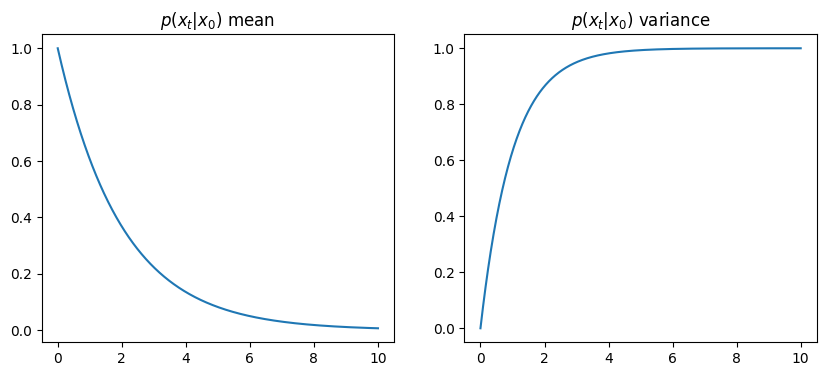

(1, 28, 28) ()
(2, 28, 28)
(32, 14, 14)
(64, 7, 7)
(128, 7, 7)
(64, 14, 14)
(32, 28, 28)
(1, 28, 28)
[1/50000] loss: 1.0095553398132324
[2000/50000] loss: 0.02876572124660015
[4000/50000] loss: 0.022822026163339615
[6000/50000] loss: 0.019831962883472443
[8000/50000] loss: 0.017729073762893677
[10000/50000] loss: 0.017738934606313705


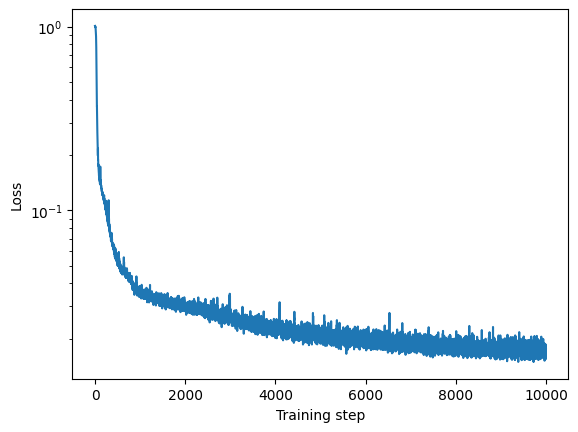

(1, 28, 28) ()
(2, 28, 28)
(32, 14, 14)
(64, 7, 7)
(128, 7, 7)
(64, 14, 14)
(32, 28, 28)
(1, 28, 28)
(1, 28, 28) ()
(2, 28, 28)
(32, 14, 14)
(64, 7, 7)
(128, 7, 7)
(64, 14, 14)
(32, 28, 28)
(1, 28, 28)
(1, 28, 28) ()
(2, 28, 28)
(32, 14, 14)
(64, 7, 7)
(128, 7, 7)
(64, 14, 14)
(32, 28, 28)
(1, 28, 28)


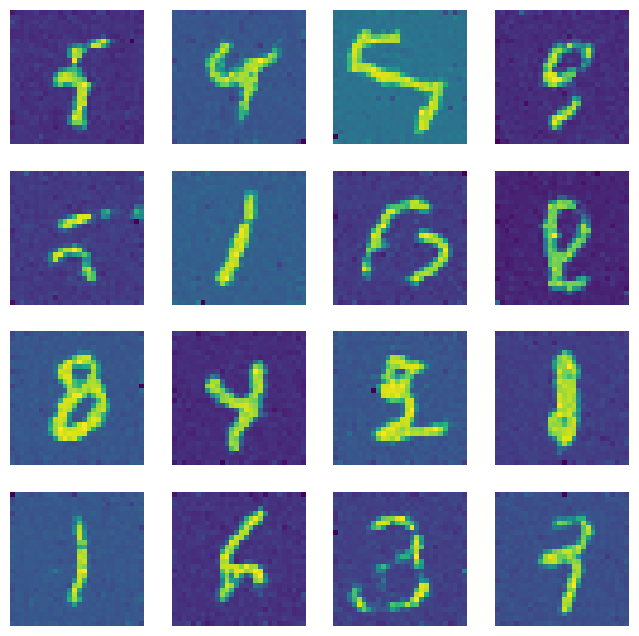

[12000/50000] loss: 0.01609773002564907
[14000/50000] loss: 0.017188183963298798
[16000/50000] loss: 0.014449330046772957
[18000/50000] loss: 0.01457695011049509
[20000/50000] loss: 0.014666931703686714


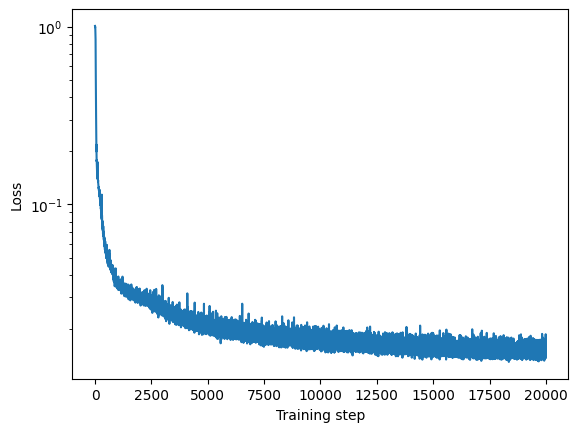

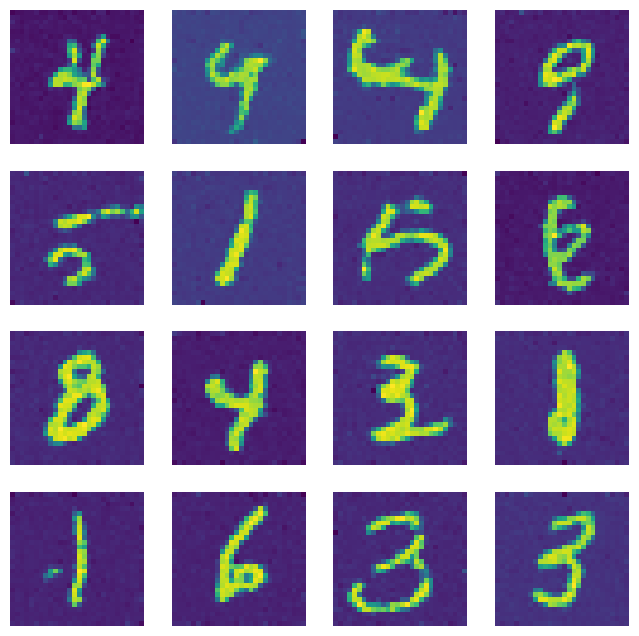

[22000/50000] loss: 0.016795052215456963
[24000/50000] loss: 0.014815538190305233
[26000/50000] loss: 0.013954076915979385
[28000/50000] loss: 0.014210999011993408
[30000/50000] loss: 0.013689715415239334


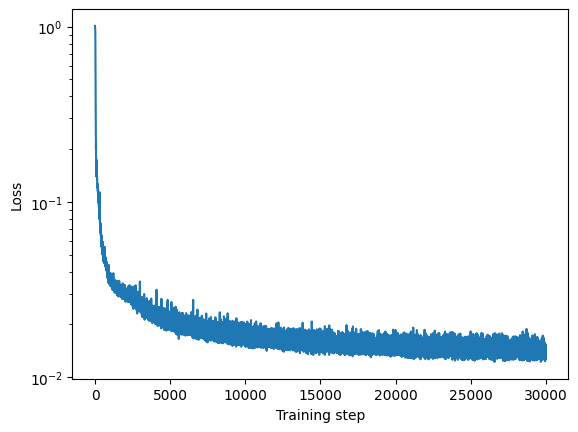

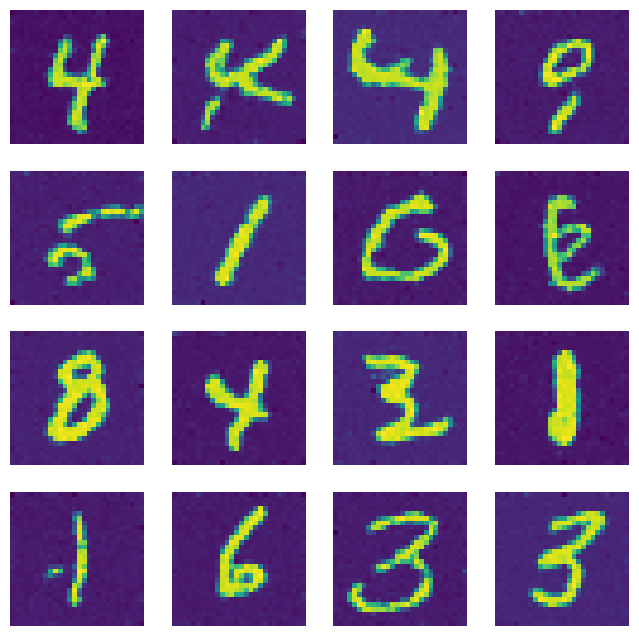

[32000/50000] loss: 0.012387784197926521
[34000/50000] loss: 0.014583495445549488
[36000/50000] loss: 0.01225135289132595
[38000/50000] loss: 0.01278630644083023
[40000/50000] loss: 0.012654227204620838


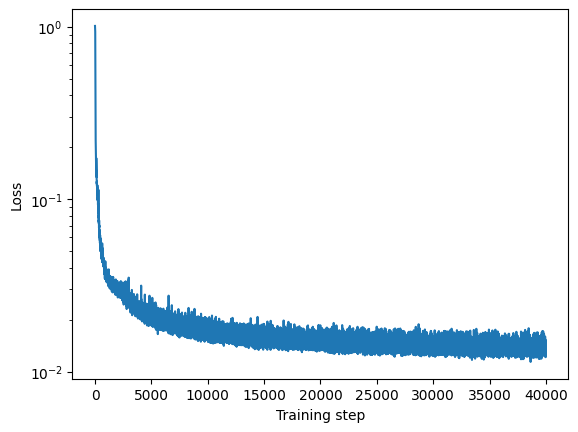

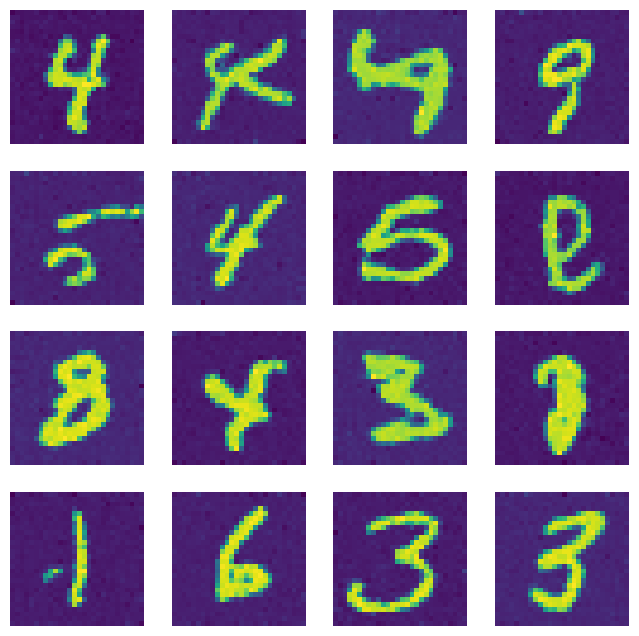

[42000/50000] loss: 0.013657571747899055
[44000/50000] loss: 0.012471240013837814
[46000/50000] loss: 0.013538079336285591
[48000/50000] loss: 0.014806683175265789
[50000/50000] loss: 0.014285480603575706


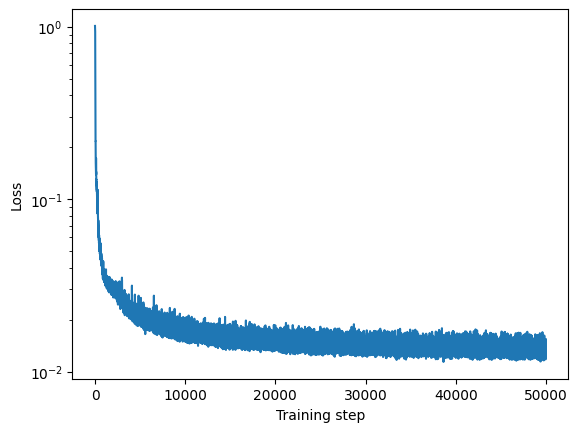

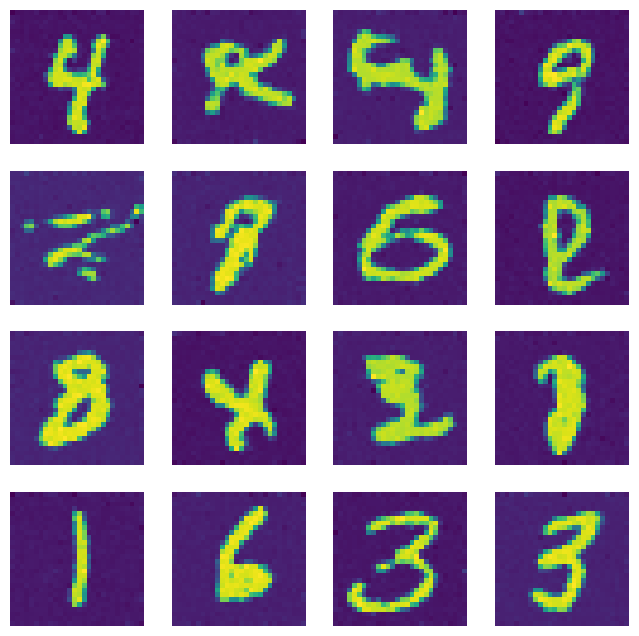

In [14]:
batch_size = 256
n_steps = 50000
key = jax.random.key(0)

# define beta, time range
int_beta = lambda t: t# can experiment with this
t1 = 10

t_ = jnp.linspace(0,t1,1000)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("$p(x_t|x_0)$ mean")
plt.plot(t_, jnp.exp(-0.5 * int_beta(t_)))
plt.subplot(1,2,2)
plt.title("$p(x_t|x_0)$ variance")
plt.plot(t_, 1 - jnp.exp(-int_beta(t_)))
plt.show()

# define model
key, key1, key2 = jax.random.split(key, 3)
#model = CNN(n_hidden_layers=4, hidden_channels=32, kernel_size=5, key=subkey)
model = UNet(in_channels=2, out_channels=1, n_hidden=32, n_levels=2, n_width=2, key=key1)
#print(model)

# define model sampling for test inputs
x_0_shape = data[0].shape
dt0 = 1e-2
keys_test = jr.split(key2, 4*4)

# define optimiser
optimiser = optax.adam(learning_rate=3e-4)
opt_state = optimiser.init(eqx.filter(model, eqx.is_inexact_array))
opt_update = optimiser.update
lossvals = []
for i in range(n_steps):

    # sample batch
    key, key1, key2 = jr.split(key, 3)
    x_0_batch = data[jr.randint(key1, (batch_size,), 0, data.shape[0])]

    # make update step
    lossval, model, opt_state = make_step(model, int_beta, t1, x_0_batch, opt_state, opt_update, key2)
    lossvals.append(lossval)

    # print/plot results
    if (i+1) % 2000 == 0 or i == 0:
        print(f"[{i+1}/{n_steps}] loss: {lossval}")
    if (i+1) % 10000 == 0:
        plt.figure()
        plt.plot(np.array(lossvals))
        plt.yscale("log")
        plt.ylabel("Loss")
        plt.xlabel("Training step")
        plt.show()
        x_0s = jax.vmap(single_sample_fn, in_axes=(None,None,None,None,None,0))(
            model, int_beta, t1, x_0_shape, dt0, keys_test)
        plt.figure(figsize=(8,8))
        for i in range(4*4):
            plt.subplot(4,4,i+1)
            plt.imshow(x_0s[i,0])
            plt.axis("off")
        plt.show()